# k=1 Spectral Identifiability (Notebook Version)

This notebook ports `experiments/sweep_k_1_to_16/k_1.py` to notebook execution.

- Hyperparameters are kept the same as the original script.
- Project root resolution uses `Path.cwd()` (no `__file__`).
- Run all cells in order to execute the full experiment and plots A-E.


In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

# Resolve project root for notebook execution
base = Path.cwd()
search_roots = [base, *base.parents]
PROJECT_ROOT = next((p for p in search_roots if (p / "src" / "common_utils.py").exists()), None)

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root. Expected src/common_utils.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

from src.common_utils import (
    calculate_rank_metrics,
    calculate_subspace_alignment_metrics,
    generate_sin_data,
    make_dataset,
    mean_std,
    min_delta_f,
    regression_accuracy,
    set_seed,
)
from src.models import MLP_L3_ReLU_BN


PROJECT_ROOT: c:\Users\WWindows10\Documents\github_project\python-neural-network-research


In [2]:
# ---------------------------------------------------
# 0. Experiment hyperparameters (edit here only)
# ---------------------------------------------------
GLOBAL_SEED = 42

# Data generation
SEQ_LEN = 1000
DT = 0.05
NUM_FREQS = 1  # k
NUM_FREQS_MIN = 1
NUM_FREQS_MAX = 30
FREQ_MIN = 1
FREQ_MAX = 60
DATA_SEED_BASE = 1000

# Training/model
LAG = 32
HIDDEN_DIM = 64
BOTTLENECK_MULTIPLIER = 4  # bottleneck_dim = multiplier * k
LR = 0.01
EPOCHS = 1000
TRAIN_SEED_BASE = 100

# Experiment repeats
NUM_EXPERIMENTS = 5
SEEDS_PER_FREQ = 10

# Metrics
ACC_TOLERANCE = 0.1
RANK_THRESHOLD = 0.05
SCREE_TOPK = 20


In [4]:
def run_experiment():

    # -----------------------------
    # 2. 사전 계산/검증
    # -----------------------------
    if NUM_FREQS < NUM_FREQS_MIN or NUM_FREQS > NUM_FREQS_MAX:
        raise ValueError(f"NUM_FREQS는 {NUM_FREQS_MIN}~{NUM_FREQS_MAX} 사이 정수여야 합니다.")

    if NUM_FREQS > (FREQ_MAX - FREQ_MIN + 1):
        raise ValueError("NUM_FREQS가 주파수 샘플링 가능한 개수를 초과했습니다.")

    theoretical_rank = 2 * NUM_FREQS
    bottleneck_dim = BOTTLENECK_MULTIPLIER * NUM_FREQS

    set_seed(GLOBAL_SEED)

    print(
        f"--- 실험 시작 (Bottleneck: {bottleneck_dim}, "
        f"주파수 {NUM_FREQS}개(Rank {theoretical_rank}), seeds={SEEDS_PER_FREQ}, "
        f"freq_range=[{FREQ_MIN}, {FREQ_MAX}]) ---"
    )

    # 세트 평균 저장 버퍼
    freq_avg_ranks, freq_std_ranks = [], []

    freq_avg_mse, freq_std_mse = [], []
    freq_avg_mae, freq_std_mae = [], []
    freq_avg_accs, freq_std_accs = [], []

    freq_avg_rank_entropy, freq_std_rank_entropy = [], []
    freq_avg_rank_gap, freq_std_rank_gap = [], []
    freq_avg_rel_rank_gap, freq_std_rel_rank_gap = [], []
    freq_avg_spectral_gap_2k, freq_std_spectral_gap_2k = [], []

    freq_avg_align_coverage, freq_std_align_coverage = [], []
    freq_avg_align_purity, freq_std_align_purity = [], []
    freq_avg_purity_norm, freq_std_purity_norm = [], []
    freq_avg_align_cosine, freq_std_align_cosine = [], []
    freq_avg_align_angle, freq_std_align_angle = [], []

    # run-level 저장 버퍼
    run_mse_all, run_mae_all, run_acc_all = [], [], []
    run_rank_th_all, run_rank_ent_all = [], []
    run_rank_gap_all, run_rel_rank_gap_all = [], []
    run_specgap_all = []
    run_coverage_all, run_purity_all = [], []
    run_purity_norm_all, run_cosine_all, run_angle_all = [], [], []

    all_principal_angles_deg = []
    all_snorm_topk = []
    set_min_delta_f = []

    mse_by_set, coverage_by_set = [], []
    rank_gap_by_set, angle_by_set = [], []

    # ---------------------------------------------------
    # 3. 실험 루프
    # ---------------------------------------------------
    for i in range(NUM_EXPERIMENTS):
        set_rng = random.Random(DATA_SEED_BASE + i)
        data, freqs = generate_sin_data(
            seq_len=SEQ_LEN,
            dt=DT,
            num_freqs=NUM_FREQS,
            freq_min=FREQ_MIN,
            freq_max=FREQ_MAX,
            rng=set_rng,
            num_freqs_min=NUM_FREQS_MIN,
            num_freqs_max=NUM_FREQS_MAX,
        )

        x_train, y_train = make_dataset(data, lag=LAG)
        set_min_delta_f.append(min_delta_f(freqs))

        current_freq_ranks = []
        current_mse, current_mae, current_freq_accs = [], [], []

        current_rank_entropy, current_rank_gap = [], []
        current_rel_rank_gap, current_spectral_gap_2k = [], []

        current_align_coverage, current_align_purity = [], []
        current_purity_norm, current_align_cosine, current_align_angle = [], [], []

        for s in range(SEEDS_PER_FREQ):
            set_seed(TRAIN_SEED_BASE + s)

            model = MLP_L3_ReLU_BN(LAG, HIDDEN_DIM, bottleneck_dim)
            optimizer = torch.optim.Adam(model.parameters(), lr=LR)
            criterion = nn.MSELoss()

            model.train()
            for _ in range(EPOCHS):
                optimizer.zero_grad()
                y_hat, _ = model(x_train)
                loss = criterion(y_hat, y_train)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                y_pred, h_val = model(x_train)
                H_np = h_val.numpy()

                # 성능 지표
                eval_mse = float(criterion(y_pred, y_train).item())
                eval_mae = float(nn.L1Loss()(y_pred, y_train).item())
                eval_acc = regression_accuracy(y_train, y_pred, tol=ACC_TOLERANCE)

                current_mse.append(eval_mse)
                current_mae.append(eval_mae)
                current_freq_accs.append(eval_acc)

                # Rank 지표
                _, S, _ = np.linalg.svd(H_np, full_matrices=False)
                rank_metrics = calculate_rank_metrics(S, threshold=RANK_THRESHOLD)
                r_th = rank_metrics["rank_threshold"]
                r_ent = rank_metrics["rank_entropy"]

                rank_gap = abs(r_th - theoretical_rank)
                rel_rank_gap = rank_gap / (theoretical_rank + 1e-12)

                idx_2k = theoretical_rank - 1
                if idx_2k < len(S):
                    sigma_2k = S[idx_2k]
                    sigma_next = S[idx_2k + 1] if (idx_2k + 1) < len(S) else 0.0
                    spectral_gap_2k = float(sigma_2k / (sigma_next + 1e-12))
                else:
                    spectral_gap_2k = np.nan

                current_freq_ranks.append(r_th)
                current_rank_entropy.append(r_ent)
                current_rank_gap.append(rank_gap)
                current_rel_rank_gap.append(rel_rank_gap)
                current_spectral_gap_2k.append(spectral_gap_2k)

                # Scree(topK)
                s_norm = S / (S[0] + 1e-12)
                topk = np.full(SCREE_TOPK, np.nan, dtype=np.float64)
                ncopy = min(SCREE_TOPK, len(s_norm))
                topk[:ncopy] = s_norm[:ncopy]
                all_snorm_topk.append(topk)

                # Alignment 지표
                align_metrics = calculate_subspace_alignment_metrics(H_np, freqs, dt=DT, lag=LAG)
                cov = align_metrics["align_coverage"]
                pur = align_metrics["align_purity"]
                pur_n = align_metrics["purity_norm"]
                cosv = align_metrics["align_mean_cosine"]
                angv = align_metrics["align_mean_angle_deg"]

                current_align_coverage.append(cov)
                current_align_purity.append(pur)
                current_purity_norm.append(pur_n)
                current_align_cosine.append(cosv)
                current_align_angle.append(angv)

                # run-level 저장
                run_mse_all.append(eval_mse)
                run_mae_all.append(eval_mae)
                run_acc_all.append(eval_acc)

                run_rank_th_all.append(r_th)
                run_rank_ent_all.append(r_ent)
                run_rank_gap_all.append(rank_gap)
                run_rel_rank_gap_all.append(rel_rank_gap)
                run_specgap_all.append(spectral_gap_2k)

                run_coverage_all.append(cov)
                run_purity_all.append(pur)
                run_purity_norm_all.append(pur_n)
                run_cosine_all.append(cosv)
                run_angle_all.append(angv)

                all_principal_angles_deg.extend(align_metrics["principal_angles_deg"].tolist())

        # 세트별 분포 저장
        mse_by_set.append(current_mse.copy())
        coverage_by_set.append(current_align_coverage.copy())
        rank_gap_by_set.append(current_rank_gap.copy())
        angle_by_set.append(current_align_angle.copy())

        # 세트 단위 평균/표준편차
        m_rank, s_rank = mean_std(current_freq_ranks)
        m_mse, s_mse = mean_std(current_mse)
        m_mae, s_mae = mean_std(current_mae)
        m_acc, s_acc = mean_std(current_freq_accs)

        m_rank_entropy, s_rank_entropy = mean_std(current_rank_entropy)
        m_rank_gap, s_rank_gap = mean_std(current_rank_gap)
        m_rel_rank_gap, s_rel_rank_gap = mean_std(current_rel_rank_gap)
        m_spec_gap, s_spec_gap = mean_std(current_spectral_gap_2k)

        m_align_cov, s_align_cov = mean_std(current_align_coverage)
        m_align_purity, s_align_purity = mean_std(current_align_purity)
        m_purity_norm, s_purity_norm = mean_std(current_purity_norm)
        m_align_cosine, s_align_cosine = mean_std(current_align_cosine)
        m_align_angle, s_align_angle = mean_std(current_align_angle)

        # 저장
        freq_avg_ranks.append(m_rank)
        freq_std_ranks.append(s_rank)

        freq_avg_mse.append(m_mse)
        freq_std_mse.append(s_mse)
        freq_avg_mae.append(m_mae)
        freq_std_mae.append(s_mae)
        freq_avg_accs.append(m_acc)
        freq_std_accs.append(s_acc)

        freq_avg_rank_entropy.append(m_rank_entropy)
        freq_std_rank_entropy.append(s_rank_entropy)
        freq_avg_rank_gap.append(m_rank_gap)
        freq_std_rank_gap.append(s_rank_gap)
        freq_avg_rel_rank_gap.append(m_rel_rank_gap)
        freq_std_rel_rank_gap.append(s_rel_rank_gap)
        freq_avg_spectral_gap_2k.append(m_spec_gap)
        freq_std_spectral_gap_2k.append(s_spec_gap)

        freq_avg_align_coverage.append(m_align_cov)
        freq_std_align_coverage.append(s_align_cov)
        freq_avg_align_purity.append(m_align_purity)
        freq_std_align_purity.append(s_align_purity)
        freq_avg_purity_norm.append(m_purity_norm)
        freq_std_purity_norm.append(s_purity_norm)
        freq_avg_align_cosine.append(m_align_cosine)
        freq_std_align_cosine.append(s_align_cosine)
        freq_avg_align_angle.append(m_align_angle)
        freq_std_align_angle.append(s_align_angle)

        # 출력
        print(f"세트 {i + 1:2d}: 주파수={freqs}")
        print(f"  MSE            = {m_mse:.6f} ± {s_mse:.6f}")
        print(f"  MAE            = {m_mae:.6f} ± {s_mae:.6f}")
        print(f"  Acc(|err|<=0.1)= {m_acc:.4f} ± {s_acc:.4f}")
        print(f"  Rank(th={RANK_THRESHOLD}) = {m_rank:.2f} ± {s_rank:.2f}")
        print(f"  Rank(entropy)  = {m_rank_entropy:.2f} ± {s_rank_entropy:.2f}")
        print(f"  rank_gap       = {m_rank_gap:.2f} ± {s_rank_gap:.2f}")
        print(f"  rel_rank_gap   = {m_rel_rank_gap:.4f} ± {s_rel_rank_gap:.4f}")
        print(f"  spectral_gap_2k= {m_spec_gap:.4f} ± {s_spec_gap:.4f}")
        print(f"  coverage       = {m_align_cov:.4f} ± {s_align_cov:.4f}")
        print(f"  purity         = {m_align_purity:.4f} ± {s_align_purity:.4f}")
        print(f"  purity_norm    = {m_purity_norm:.4f} ± {s_purity_norm:.4f}")
        print(f"  cosine         = {m_align_cosine:.4f} ± {s_align_cosine:.4f}")
        print(f"  angle(deg)     = {m_align_angle:.2f} ± {s_align_angle:.2f}")

    # ---------------------------------------------------
    # 4. 전체 요약
    # ---------------------------------------------------
    print("\n=== 최종 결과 요약 (세트 평균들의 평균 ± 표준편차) ===")

    ov_rank_m, ov_rank_s = mean_std(freq_avg_ranks)
    ov_mse_m, ov_mse_s = mean_std(freq_avg_mse)
    ov_mae_m, ov_mae_s = mean_std(freq_avg_mae)
    ov_acc_m, ov_acc_s = mean_std(freq_avg_accs)

    ov_rank_entropy_m, ov_rank_entropy_s = mean_std(freq_avg_rank_entropy)
    ov_rank_gap_m, ov_rank_gap_s = mean_std(freq_avg_rank_gap)
    ov_rel_rank_gap_m, ov_rel_rank_gap_s = mean_std(freq_avg_rel_rank_gap)
    ov_spec_gap_m, ov_spec_gap_s = mean_std(freq_avg_spectral_gap_2k)

    ov_align_cov_m, ov_align_cov_s = mean_std(freq_avg_align_coverage)
    ov_align_purity_m, ov_align_purity_s = mean_std(freq_avg_align_purity)
    ov_purity_norm_m, ov_purity_norm_s = mean_std(freq_avg_purity_norm)
    ov_align_cosine_m, ov_align_cosine_s = mean_std(freq_avg_align_cosine)
    ov_align_angle_m, ov_align_angle_s = mean_std(freq_avg_align_angle)

    print(f"MSE: {ov_mse_m:.6f} ± {ov_mse_s:.6f}")
    print(f"MAE: {ov_mae_m:.6f} ± {ov_mae_s:.6f}")
    print(f"Acc(|err|<=0.1): {ov_acc_m:.4f} ± {ov_acc_s:.4f}")
    print(f"Rank(th={RANK_THRESHOLD}): {ov_rank_m:.2f} ± {ov_rank_s:.2f}")
    print(f"Rank(entropy): {ov_rank_entropy_m:.2f} ± {ov_rank_entropy_s:.2f}")
    print(f"rank_gap: {ov_rank_gap_m:.2f} ± {ov_rank_gap_s:.2f}")
    print(f"rel_rank_gap: {ov_rel_rank_gap_m:.4f} ± {ov_rel_rank_gap_s:.4f}")
    print(f"spectral_gap_2k: {ov_spec_gap_m:.4f} ± {ov_spec_gap_s:.4f}")
    print(f"coverage: {ov_align_cov_m:.4f} ± {ov_align_cov_s:.4f}")
    print(f"purity: {ov_align_purity_m:.4f} ± {ov_align_purity_s:.4f}")
    print(f"purity_norm: {ov_purity_norm_m:.4f} ± {ov_purity_norm_s:.4f}")
    print(f"cosine: {ov_align_cosine_m:.4f} ± {ov_align_cosine_s:.4f}")
    print(f"angle(deg): {ov_align_angle_m:.2f} ± {ov_align_angle_s:.2f}")

    # ---------------------------------------------------
    # 5. 시각화 A
    # ---------------------------------------------------
    fig1, axes = plt.subplots(3, 2, figsize=(14, 14))

    axes[0, 0].scatter(run_rank_gap_all, run_mse_all, alpha=0.45, s=18, color="tab:blue")
    axes[0, 0].set_xlabel("rank_gap = |rank_threshold - 2k|")
    axes[0, 0].set_ylabel("MSE")
    axes[0, 0].set_title("Loss vs Rank Gap")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].scatter(run_coverage_all, run_mse_all, alpha=0.45, s=18, color="tab:green")
    axes[0, 1].set_xlabel("coverage")
    axes[0, 1].set_ylabel("MSE")
    axes[0, 1].set_title("Loss vs Coverage")
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].hist(all_principal_angles_deg, bins=40, color="tab:orange", alpha=0.8)
    axes[1, 0].set_xlabel("Principal angle (deg)")
    axes[1, 0].set_ylabel("Count")
    axes[1, 0].set_title("Principal Angle Histogram")
    axes[1, 0].grid(True, alpha=0.3)

    snorm_mat = np.array(all_snorm_topk, dtype=np.float64)
    snorm_mean = np.nanmean(snorm_mat, axis=0)
    x_scree = np.arange(1, SCREE_TOPK + 1)

    axes[1, 1].plot(x_scree, snorm_mean, "o-", color="tab:red")
    axes[1, 1].set_xlabel("Singular value index")
    axes[1, 1].set_ylabel("Normalized singular value")
    axes[1, 1].set_title(f"Scree Plot (Top {SCREE_TOPK}, mean over runs)")
    axes[1, 1].grid(True, alpha=0.3)

    x_df = np.array(set_min_delta_f, dtype=np.float64)
    y_cov = np.array(freq_avg_align_coverage, dtype=np.float64)
    mask = np.isfinite(x_df) & np.isfinite(y_cov)

    axes[2, 0].scatter(x_df[mask], y_cov[mask], alpha=0.8, color="tab:purple")
    axes[2, 0].set_xlabel("min Δf within set")
    axes[2, 0].set_ylabel("coverage (set mean)")
    axes[2, 0].set_title("Coverage vs min Δf")
    axes[2, 0].grid(True, alpha=0.3)

    y_ang = np.array(freq_avg_align_angle, dtype=np.float64)
    mask2 = np.isfinite(x_df) & np.isfinite(y_ang)

    axes[2, 1].scatter(x_df[mask2], y_ang[mask2], alpha=0.8, color="tab:brown")
    axes[2, 1].set_xlabel("min Δf within set")
    axes[2, 1].set_ylabel("mean angle (deg, set mean)")
    axes[2, 1].set_title("Mean Angle vs min Δf")
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # 6. 시각화 B
    # ---------------------------------------------------
    x_set = np.arange(1, NUM_EXPERIMENTS + 1)
    fig2, ax2 = plt.subplots(3, 2, figsize=(14, 14))

    ax2[0, 0].errorbar(x_set, freq_avg_mse, yerr=freq_std_mse, fmt="o-", capsize=3, label="MSE")
    ax2[0, 0].errorbar(x_set, freq_avg_mae, yerr=freq_std_mae, fmt="s-", capsize=3, label="MAE")
    ax2[0, 0].set_title("Set-wise Error Trend")
    ax2[0, 0].set_xlabel("Set index")
    ax2[0, 0].set_ylabel("Error")
    ax2[0, 0].legend()
    ax2[0, 0].grid(True, alpha=0.3)

    ax2[0, 1].errorbar(x_set, freq_avg_accs, yerr=freq_std_accs, fmt="o-", capsize=3, color="tab:green")
    ax2[0, 1].set_title("Set-wise Accuracy Trend")
    ax2[0, 1].set_xlabel("Set index")
    ax2[0, 1].set_ylabel("Acc(|err|<=0.1)")
    ax2[0, 1].grid(True, alpha=0.3)

    ax2[1, 0].errorbar(x_set, freq_avg_ranks, yerr=freq_std_ranks, fmt="o-", capsize=3, label="rank_threshold")
    ax2[1, 0].axhline(theoretical_rank, color="red", linestyle="--", label=f"theory=2k={theoretical_rank}")
    ax2[1, 0].set_title("Set-wise Rank(threshold)")
    ax2[1, 0].set_xlabel("Set index")
    ax2[1, 0].set_ylabel("Rank")
    ax2[1, 0].legend()
    ax2[1, 0].grid(True, alpha=0.3)

    ax2[1, 1].errorbar(
        x_set,
        freq_avg_rank_entropy,
        yerr=freq_std_rank_entropy,
        fmt="o-",
        capsize=3,
        color="tab:orange",
    )
    ax2[1, 1].set_title("Set-wise Rank(entropy)")
    ax2[1, 1].set_xlabel("Set index")
    ax2[1, 1].set_ylabel("Entropy Rank")
    ax2[1, 1].grid(True, alpha=0.3)

    ax2[2, 0].errorbar(
        x_set, freq_avg_align_coverage, yerr=freq_std_align_coverage, fmt="o-", capsize=3, label="coverage"
    )
    ax2[2, 0].errorbar(
        x_set, freq_avg_purity_norm, yerr=freq_std_purity_norm, fmt="s-", capsize=3, label="purity_norm"
    )
    ax2[2, 0].errorbar(
        x_set, freq_avg_align_cosine, yerr=freq_std_align_cosine, fmt="^-", capsize=3, label="mean_cosine"
    )
    ax2[2, 0].set_title("Set-wise Alignment Scores")
    ax2[2, 0].set_xlabel("Set index")
    ax2[2, 0].set_ylabel("Score")
    ax2[2, 0].legend()
    ax2[2, 0].grid(True, alpha=0.3)

    ax2[2, 1].errorbar(
        x_set, freq_avg_align_angle, yerr=freq_std_align_angle, fmt="o-", capsize=3, color="tab:brown"
    )
    ax2[2, 1].set_title("Set-wise Mean Principal Angle")
    ax2[2, 1].set_xlabel("Set index")
    ax2[2, 1].set_ylabel("Angle (deg)")
    ax2[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # 7. 시각화 C
    # ---------------------------------------------------
    fig3, ax3 = plt.subplots(2, 2, figsize=(14, 10))

    ax3[0, 0].boxplot(mse_by_set, showfliers=False)
    ax3[0, 0].set_title("MSE Distribution per Set")
    ax3[0, 0].set_xlabel("Set index")
    ax3[0, 0].set_ylabel("MSE")
    ax3[0, 0].grid(True, alpha=0.2)

    ax3[0, 1].boxplot(coverage_by_set, showfliers=False)
    ax3[0, 1].set_title("Coverage Distribution per Set")
    ax3[0, 1].set_xlabel("Set index")
    ax3[0, 1].set_ylabel("Coverage")
    ax3[0, 1].grid(True, alpha=0.2)

    ax3[1, 0].boxplot(rank_gap_by_set, showfliers=False)
    ax3[1, 0].set_title("Rank Gap Distribution per Set")
    ax3[1, 0].set_xlabel("Set index")
    ax3[1, 0].set_ylabel("Rank Gap")
    ax3[1, 0].grid(True, alpha=0.2)

    ax3[1, 1].boxplot(angle_by_set, showfliers=False)
    ax3[1, 1].set_title("Mean Angle Distribution per Set")
    ax3[1, 1].set_xlabel("Set index")
    ax3[1, 1].set_ylabel("Angle (deg)")
    ax3[1, 1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # 8. 시각화 D
    # ---------------------------------------------------
    metric_labels = [
        "MSE",
        "MAE",
        "Acc",
        "Rank_th",
        "Rank_ent",
        "Rank_gap",
        "Rel_rank_gap",
        "Spec_gap_2k",
        "Coverage",
        "Purity_norm",
        "Cosine",
        "Angle_deg",
    ]

    metric_matrix = np.array(
        [
            run_mse_all,
            run_mae_all,
            run_acc_all,
            run_rank_th_all,
            run_rank_ent_all,
            run_rank_gap_all,
            run_rel_rank_gap_all,
            run_specgap_all,
            run_coverage_all,
            run_purity_norm_all,
            run_cosine_all,
            run_angle_all,
        ],
        dtype=np.float64,
    )

    for r in range(metric_matrix.shape[0]):
        row = metric_matrix[r]
        if np.any(~np.isfinite(row)):
            med = np.nanmedian(row)
            if not np.isfinite(med):
                med = 0.0
            row[~np.isfinite(row)] = med
            metric_matrix[r] = row

    corr = np.corrcoef(metric_matrix)
    corr = np.nan_to_num(corr, nan=0.0)

    fig4, ax4 = plt.subplots(figsize=(10, 8))
    im = ax4.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

    ax4.set_xticks(np.arange(len(metric_labels)))
    ax4.set_yticks(np.arange(len(metric_labels)))
    ax4.set_xticklabels(metric_labels, rotation=45, ha="right")
    ax4.set_yticklabels(metric_labels)
    ax4.set_title("Run-level Metric Correlation (Pearson)")

    for ii in range(corr.shape[0]):
        for jj in range(corr.shape[1]):
            ax4.text(jj, ii, f"{corr[ii, jj]:.2f}", ha="center", va="center", fontsize=8, color="black")

    fig4.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # 9. 시각화 E
    # ---------------------------------------------------
    fig5, ax5 = plt.subplots(2, 2, figsize=(12, 9))

    ax5[0, 0].hist(run_rank_gap_all, bins=30, color="tab:blue", alpha=0.8)
    ax5[0, 0].set_title("Distribution: Rank Gap")
    ax5[0, 0].set_xlabel("rank_gap")
    ax5[0, 0].set_ylabel("Count")
    ax5[0, 0].grid(True, alpha=0.2)

    ax5[0, 1].hist(run_coverage_all, bins=30, color="tab:green", alpha=0.8)
    ax5[0, 1].set_title("Distribution: Coverage")
    ax5[0, 1].set_xlabel("coverage")
    ax5[0, 1].set_ylabel("Count")
    ax5[0, 1].grid(True, alpha=0.2)

    ax5[1, 0].hist(run_specgap_all, bins=30, color="tab:red", alpha=0.8)
    ax5[1, 0].set_title("Distribution: spectral_gap_2k")
    ax5[1, 0].set_xlabel("spectral_gap_2k")
    ax5[1, 0].set_ylabel("Count")
    ax5[1, 0].grid(True, alpha=0.2)

    ax5[1, 1].hist(run_angle_all, bins=30, color="tab:orange", alpha=0.8)
    ax5[1, 1].set_title("Distribution: Mean Angle (deg)")
    ax5[1, 1].set_xlabel("angle (deg)")
    ax5[1, 1].set_ylabel("Count")
    ax5[1, 1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    return {
        "freq_avg_mse": freq_avg_mse,
        "freq_avg_mae": freq_avg_mae,
        "freq_avg_accs": freq_avg_accs,
        "freq_avg_ranks": freq_avg_ranks,
        "freq_avg_align_coverage": freq_avg_align_coverage,
        "freq_avg_align_angle": freq_avg_align_angle,
    }


--- 실험 시작 (Bottleneck: 4, 주파수 1개(Rank 2), seeds=10, freq_range=[1, 60]) ---
세트  1: 주파수=(50,)
  MSE            = 0.000001 ± 0.000000
  MAE            = 0.000902 ± 0.000088
  Acc(|err|<=0.1)= 1.0000 ± 0.0000
  Rank(th=0.05) = 2.60 ± 0.52
  Rank(entropy)  = 2.32 ± 0.11
  rank_gap       = 0.60 ± 0.52
  rel_rank_gap   = 0.3000 ± 0.2582
  spectral_gap_2k= 10.4215 ± 4.3869
  coverage       = 0.9980 ± 0.0018
  purity         = 0.4990 ± 0.0009
  purity_norm    = 0.9980 ± 0.0018
  cosine         = 0.9990 ± 0.0009
  angle(deg)     = 1.66 ± 0.80
세트  2: 주파수=(51,)
  MSE            = 0.000001 ± 0.000000
  MAE            = 0.000926 ± 0.000149
  Acc(|err|<=0.1)= 1.0000 ± 0.0000
  Rank(th=0.05) = 2.80 ± 0.79
  Rank(entropy)  = 2.34 ± 0.27
  rank_gap       = 0.80 ± 0.79
  rel_rank_gap   = 0.4000 ± 0.3944
  spectral_gap_2k= 9.0585 ± 5.7573
  coverage       = 0.9966 ± 0.0041
  purity         = 0.4983 ± 0.0021
  purity_norm    = 0.9966 ± 0.0041
  cosine         = 0.9983 ± 0.0021
  angle(deg)     = 2.01 ± 1.

C:\Users\WWindows10\AppData\Local\Temp\ipykernel_12832\3459896765.py:305: RuntimeWarning: Mean of empty slice
  snorm_mean = np.nanmean(snorm_mat, axis=0)


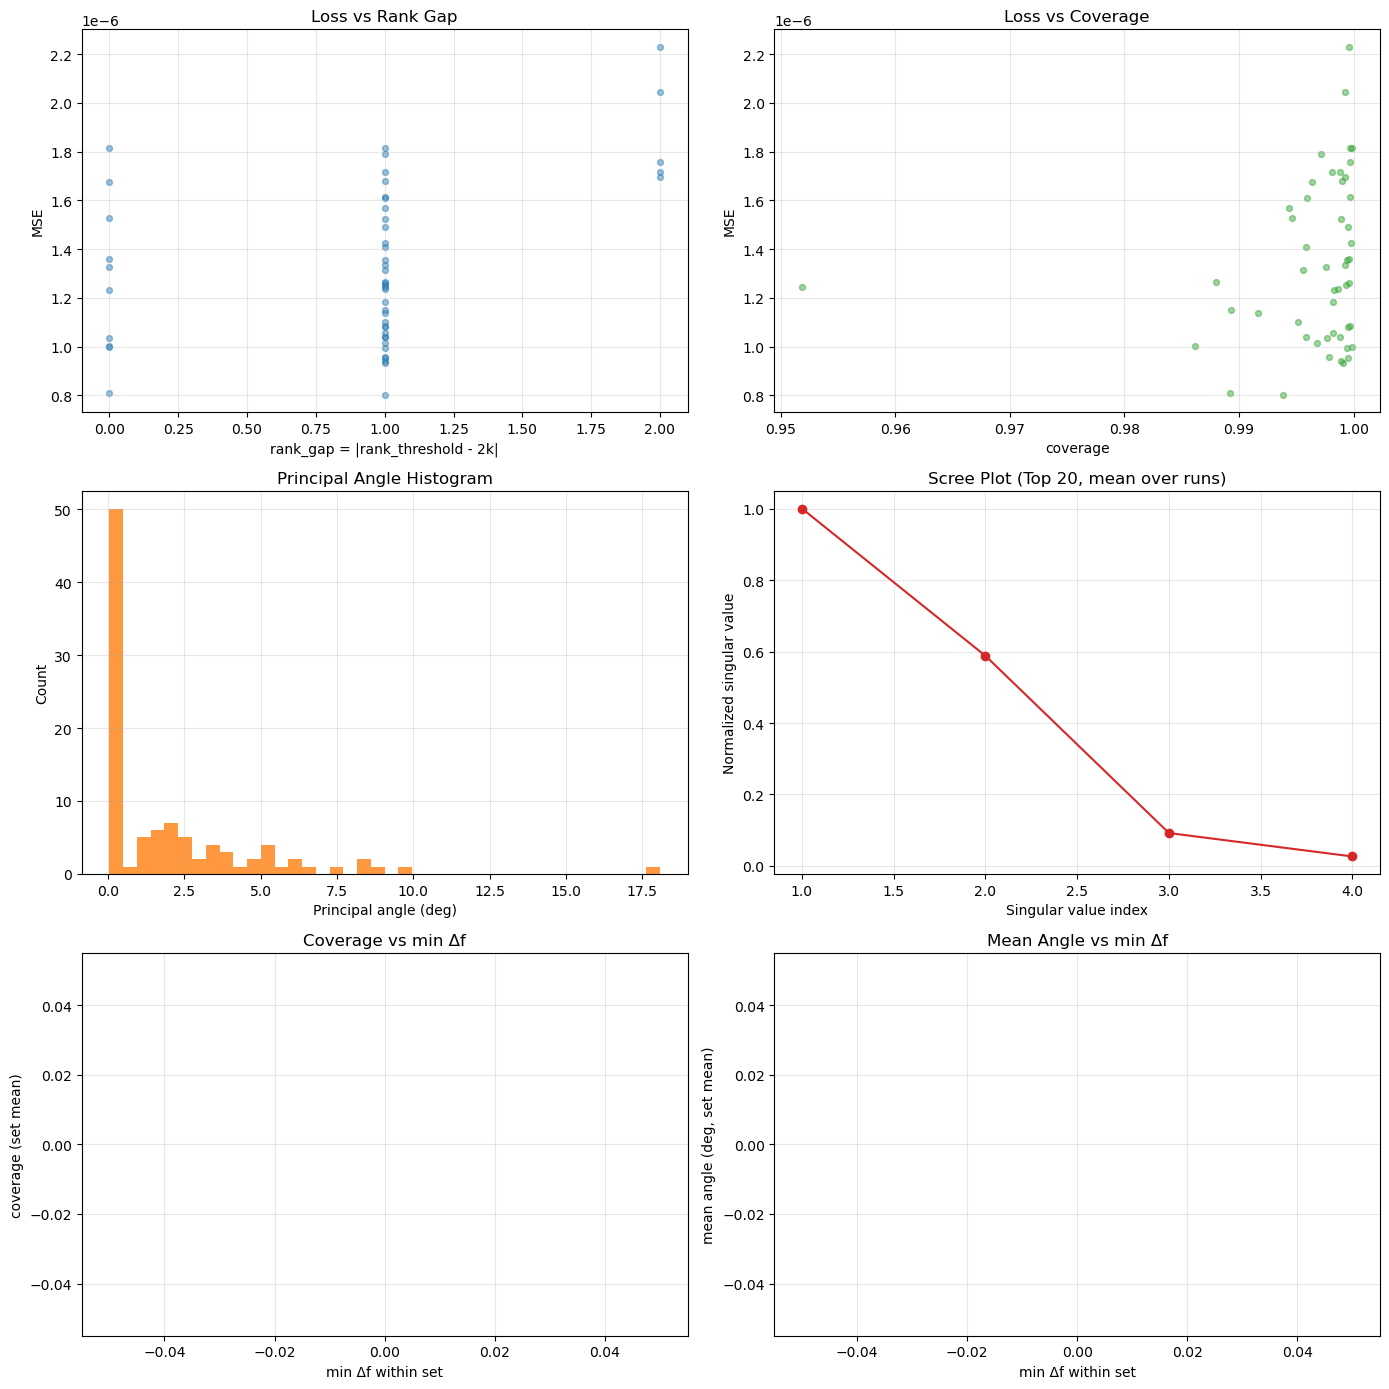

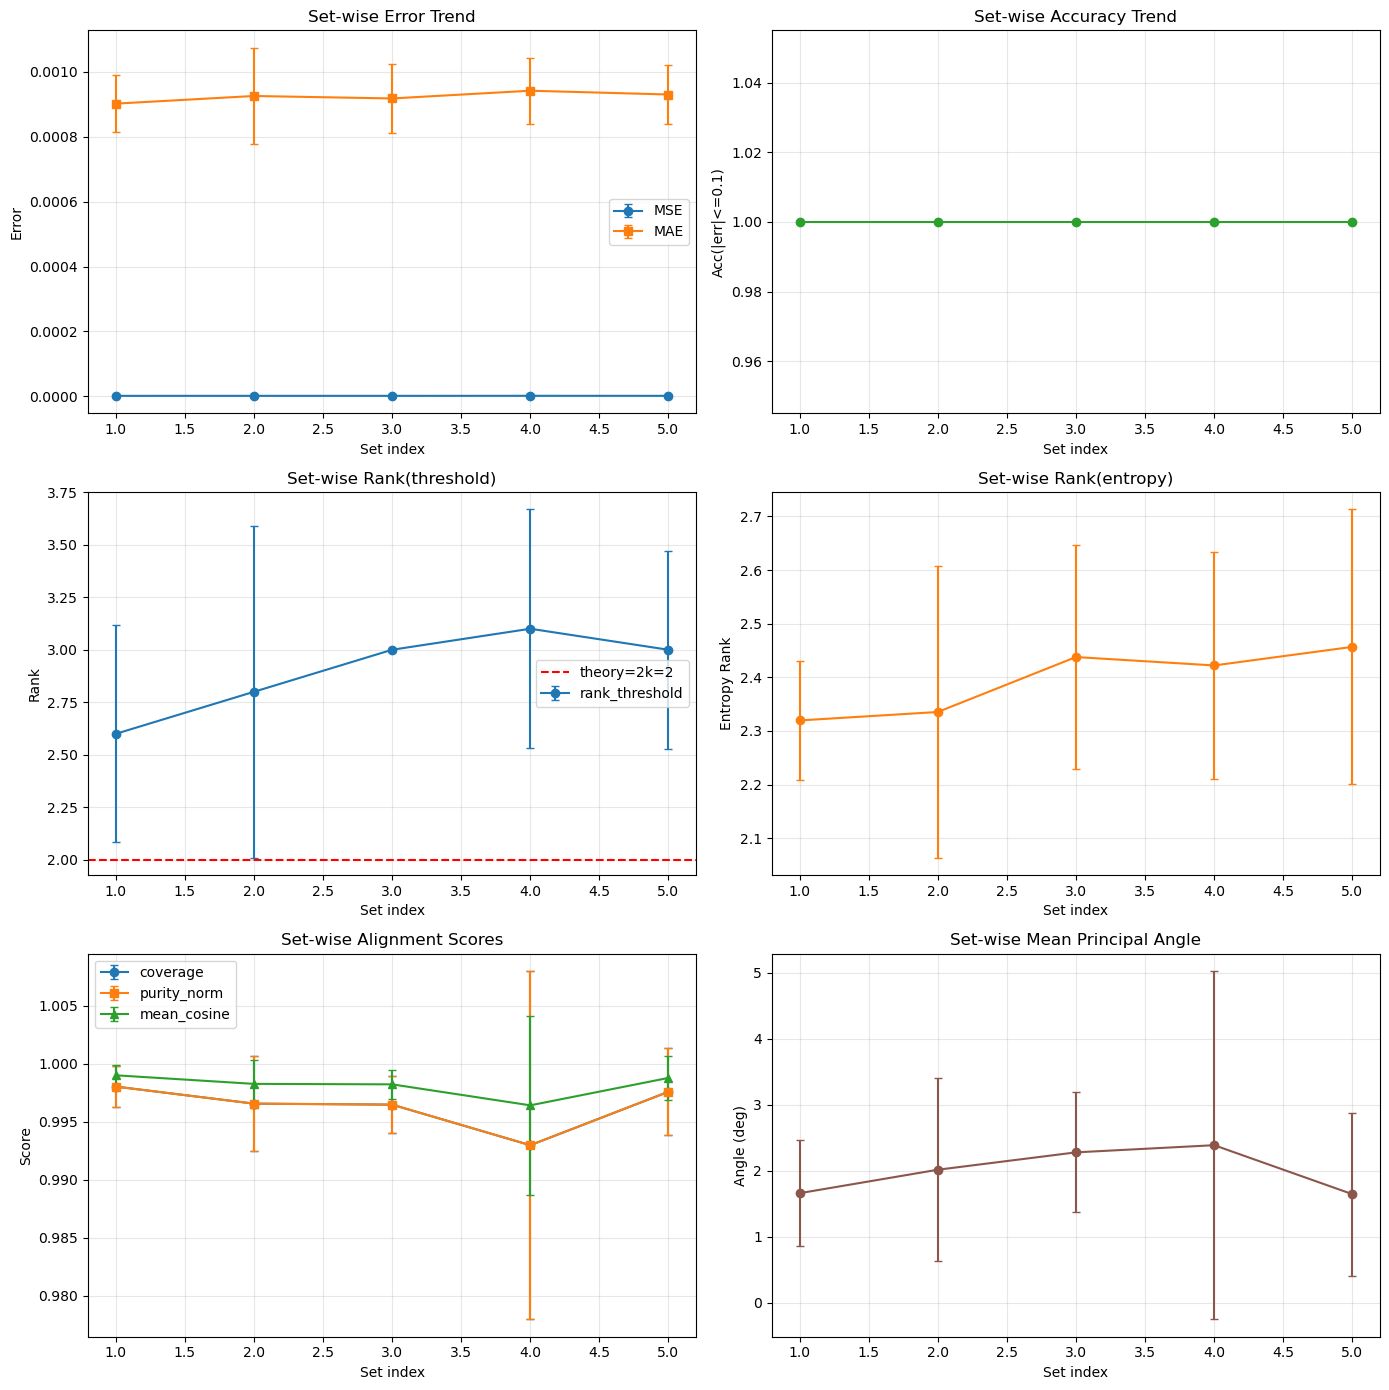

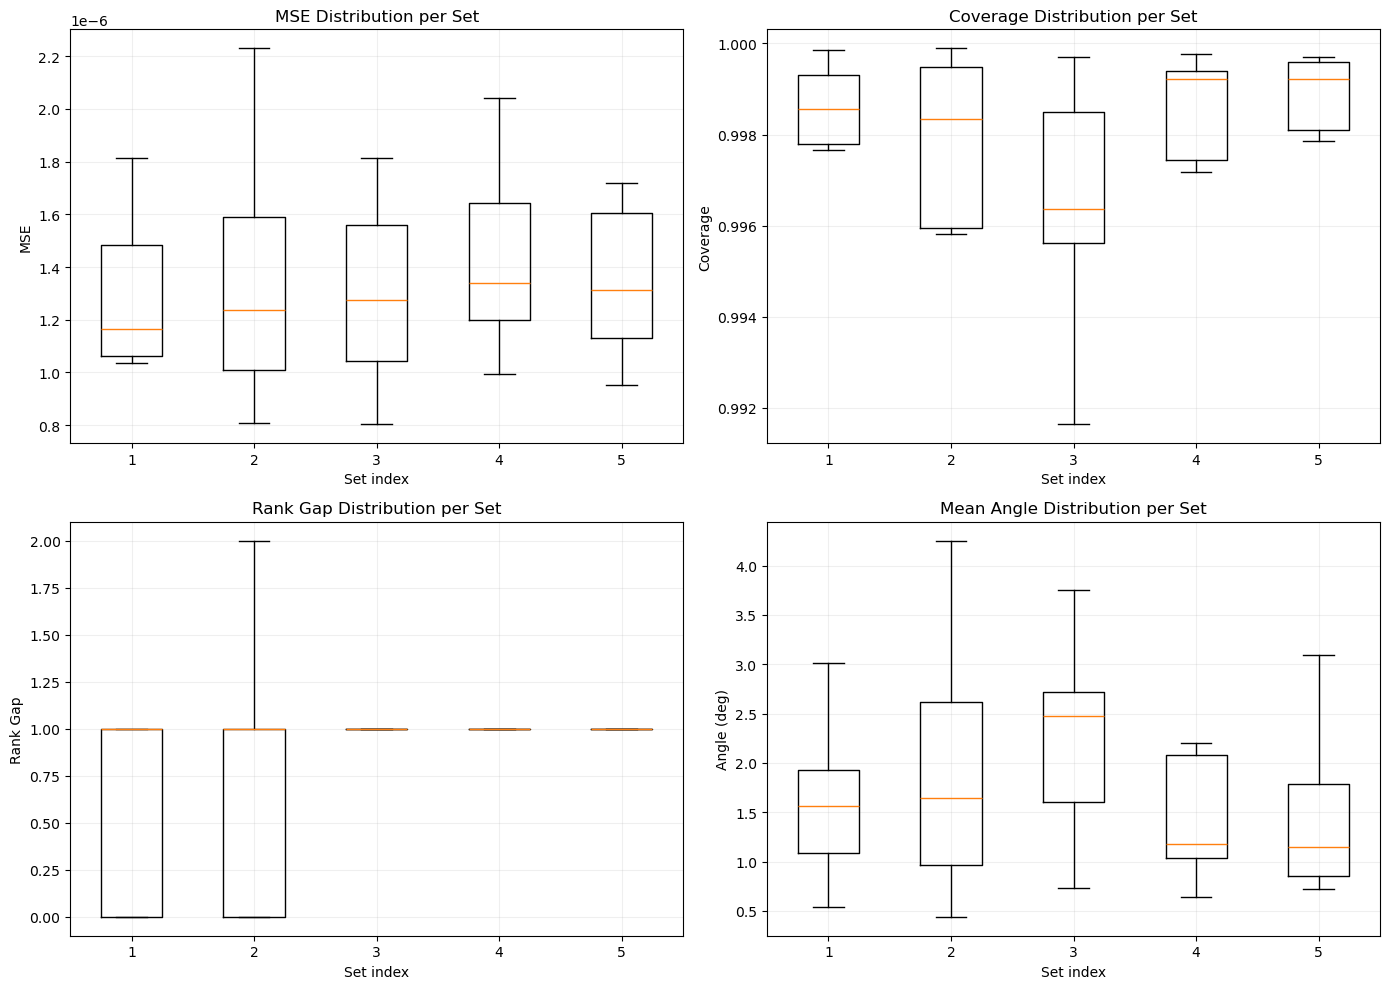

c:\Users\WWindows10\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\WWindows10\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


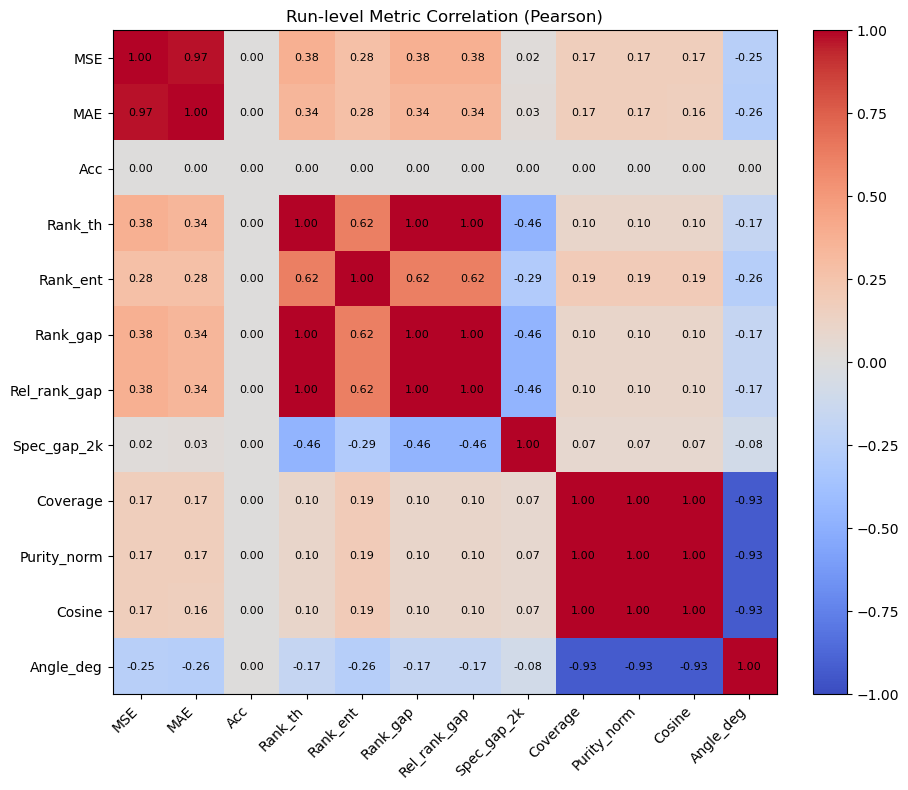

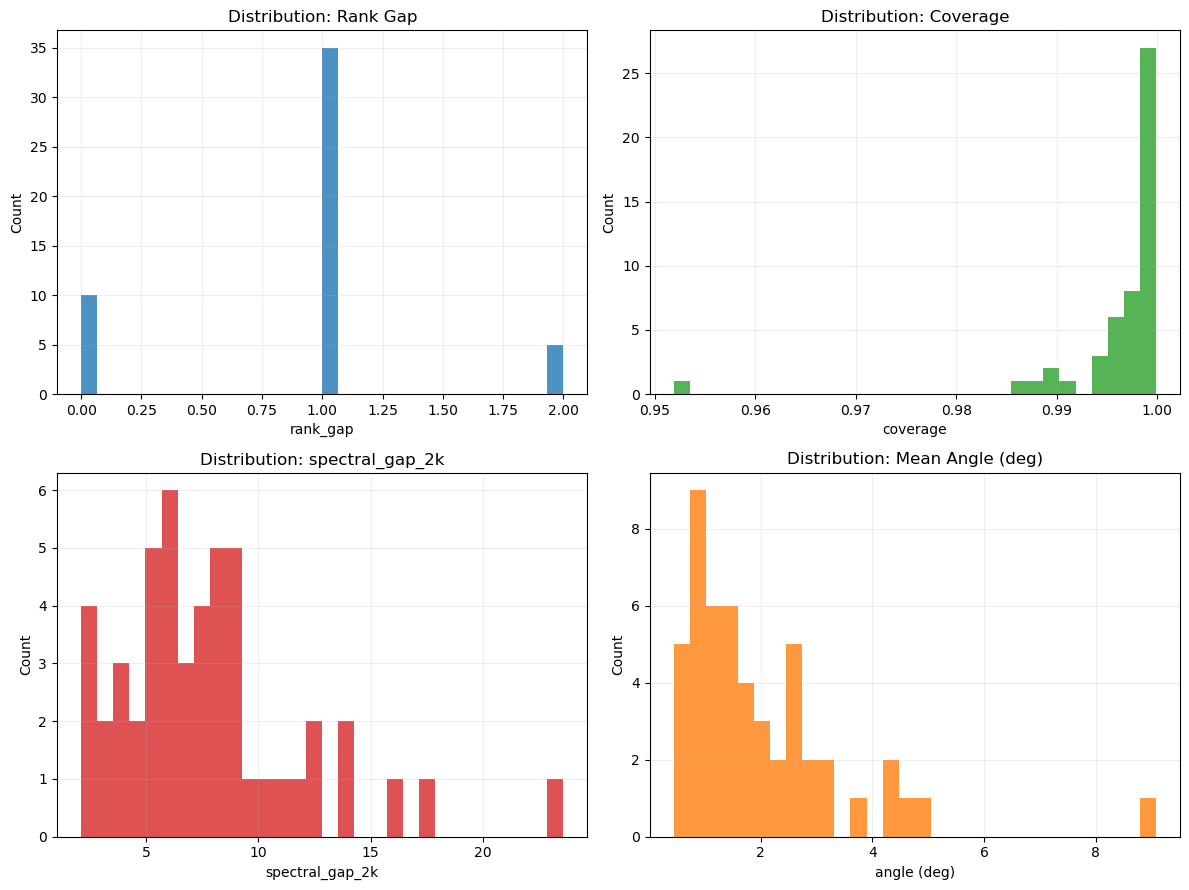


Returned keys: ['freq_avg_accs', 'freq_avg_align_angle', 'freq_avg_align_coverage', 'freq_avg_mae', 'freq_avg_mse', 'freq_avg_ranks']


In [6]:
results = run_experiment()

# optional quick peek
print("\nReturned keys:", sorted(results.keys()))
